## Imports

In [1]:
%load_ext autoreload
%autoreload 2
from imports import *
datadir, dirnameb, device, device0 = init_vars()

import re
from skimage.measure import find_contours
from scipy.ndimage import gaussian_filter, sobel, binary_dilation
from collections import defaultdict
#from scipy.stats import pearsonr, spearmanr, linregress
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.signal import find_peaks

2026 May 13: bevil running on ca3
Project:  ColorV1
  cuda0: NVIDIA RTX 6000 Ada Generation
  cuda1: NVIDIA RTX A6000
Device assigned: cuda:0
Loaded additional packages:
  CU DDPIutils ETutils readout_fit MBET pproc cal cme RFutils multidata 
Datadir: /home/DATA/ColorV1/
Dirname: /home/bevil/


## Functions to analyze filters

In [2]:
f_labels = ["lin", "q1", "q2"]
chrom_chan_labels = ["Lum", "L-M", "S"]

def get_mask(I):
    I = I.astype(np.float32) 
    # smoothing
    I_smooth = gaussian_filter(I, sigma=0.2, mode='reflect')

    # compute gradient
    Gx = sobel(I_smooth, axis=1)
    Gy = sobel(I_smooth, axis=0)
    Gmag = np.hypot(Gx, Gy) 
    max_g = Gmag.max()
    if max_g > 0:
        thresh = np.percentile(Gmag, 92.5) # was 92.5
    else:
        thresh = 0

    mask = (Gmag >= thresh) | (I >= 0.1 * I.max())

    # fill in hole
    mask = binary_dilation(mask, structure=np.ones((3,3)))

    return mask

def get_weighted_filters(gqm, data, cellidx):
    filtws = RFutils.GQM_filtws(gqm, data,cellidx, 0,2)
    wL = deepcopy(gqm.get_weights())
    wQ = deepcopy(gqm.get_weights(ffnet_target=2))
    filters = np.concatenate([wL, wQ], axis=4)
    weights = filtws.reshape(1, 1, 1, 1, 3)
    filters = filters * weights
    return filters

def assess_quality(filters, chrom_chan_label, f_label):

    # input: gqm filters weighted by filtws
    
    chrom_chan = chrom_chan_labels.index(chrom_chan_label)
    f = f_labels.index(f_label)

    # get best lag -- highest variance
    best_lag = np.argmax(np.var(filters[chrom_chan, :, :, :, f].reshape(-1, 10), axis=0))
    
    isGood = True

    n_chrom_chan, NX, NY, nlags, n_filts = filters.shape
    filters2 = filters ** 2

    # compute mean and std of each pixel (squared) across lags for each filter
    filters2_mean = np.reshape(np.mean(filters2, axis=3), (n_chrom_chan, NX, NY, n_filts)) 
    filters2_std = np.reshape(np.std(filters2, axis=3), (n_chrom_chan, NX, NY, n_filts)) 

    # get std and mean images for filter of interest
    thisFilter_std = np.reshape(filters2_std[chrom_chan,:,:,f], (NX, NY))
    thisFilter_mean = np.reshape(filters2_mean[chrom_chan,:,:,f], (NX, NY))

    # create mask around RF in filter
    mask = get_mask(thisFilter_std)
    thisFilter_std_masked = thisFilter_std * mask

    # compute "SNR": sum of std image in mask divide by sum of std image outside of mask

    std_everywhere = np.sum(thisFilter_std)
    SNR = np.sum(thisFilter_std*mask)/np.sum(thisFilter_std*~mask)
    SNR_db = 10*np.log10(SNR)

    # temporal metrics 
    
    # look at time course at "best pixel": temporal kernel
    filters2_std = np.std(filters2[chrom_chan,:,:,:,f],axis=2) 
    best_row, best_col = np.where(thisFilter_std == np.max(thisFilter_std)) # best pixel is one that varies most across lags

    # temporal kernel

    tkern = np.ravel(filters[chrom_chan,best_row,best_col,:,f].reshape(10,-1))

   # tkern_slope= np.abs(tkern[-1] - tkern[1])/np.ptp(tkern)
    
    tkern_mean_crossings = np.sum(np.diff(np.sign(tkern - np.mean(tkern))) != 0)
    
    #num_tkern_extrema = np.sum(np.abs(tkern - tkern.mean()) > 1.5*np.std(tkern))
    tkern_standardized = deepcopy(tkern)
    tkern_standardized -= tkern.mean()
    tkern_standardized /= np.max(np.abs(tkern_standardized))
    num_tkern_extrema = np.sum(np.abs(tkern_standardized) >= 0.5)

    tkern_slope = np.abs(tkern_standardized[-1]-tkern_standardized[0])

    tkern_first_deriv_energy = np.sum((np.diff(tkern_standardized)**2))
    
    # spatial metrics

    filter_at_best_lag = np.reshape(filters[chrom_chan, :,:,best_lag, f], (NX, NY))
    F = np.fft.fftshift(np.fft.fft2(filter_at_best_lag))
    P = np.abs(F)**2
    spatial_pr = (P.sum()**2)/np.sum(P**2)

    h,w = filter_at_best_lag.shape

    ky, kx = np.mgrid[-h//2:h//2, -w//2:w//2]
    r = np.sqrt(kx**2 + ky**2)
    hf = np.sum((r**2) * P) / np.sum(P)

    S = np.log1p(np.abs(F)**2)
    
    # finite differences
    dx = np.diff(S, axis=1)
    dy = np.diff(S, axis=0)

    # match shapes
    dx = dx[:-1, :]
    dy = dy[:, :-1]

    # isotropic TV
    tv_sf = np.sum(np.sqrt(dx**2 + dy**2))/np.sum(S)

 # determine if filter is bad according to the following criteria:
    isBad = (
        #SNR_db < 2.0
        tkern_slope > 0.5
        or tkern_mean_crossings > num_tkern_extrema + 1
        or tkern_mean_crossings > int(nlags/2)
        or best_lag <=1
        or spatial_pr > 110
        or tv_sf > 2
        or tkern_first_deriv_energy >4.75
    )
    metrics = {}
    metrics['SNR_db'] = SNR_db
    metrics['tkern_mean_crossings'] = tkern_mean_crossings
    metrics['tkern_slope'] = tkern_slope
    metrics['spatial_pr'] = spatial_pr
    metrics['tv_sf'] = tv_sf
    metrics['num_tkern_extrema'] = num_tkern_extrema
    metrics['tkern_first_deriv_energy'] = tkern_first_deriv_energy
    isGood = isGood and not isBad
    return isGood, best_lag, metrics

def analyze_RF_structure(filters, chrom_chan_label, f_label, best_lag, toPlot=0):

    chrom_chan = chrom_chan_labels.index(chrom_chan_label)
    f = f_labels.index(f_label)
    n_chrom_chan, NX, NY, nlags, n_filts = filters.shape
    filters2 = filters ** 2
    filters2_ON = np.where(filters > 0, filters2, 0)
    filters2_OFF = np.where(filters < 0, filters2, 0)
    
    filters2_std = np.reshape(np.std(filters2, axis=3), (n_chrom_chan, NX, NY, n_filts)) 
    thisFilter_std = np.reshape(filters2_std[chrom_chan,:,:,f], (NX, NY))
    mask = get_mask(thisFilter_std)

    # determine ON and OFF subunits
    ON_RF = np.reshape(filters2_ON[chrom_chan,:,:,best_lag,f], (NX, NY)) * mask
    OFF_RF = np.reshape(filters2_OFF[chrom_chan,:,:,best_lag,f], (NX, NY)) * mask

    # compute rms of ON and OFF subunits
    ON_RF_rms = np.sqrt(np.mean(ON_RF**2))
    OFF_RF_rms = np.sqrt(np.mean(OFF_RF**2))

    # binarize ON and OFF subunit images and compute area by summing pixels in binarized images
    ON_RF_bin = (ON_RF > 0.05 * np.max(ON_RF))
    ON_RFarea = np.sum(ON_RF_bin)

    OFF_RF_bin = (OFF_RF > 0.05 * np.max(OFF_RF))
    OFF_RFarea = np.sum(OFF_RF_bin)

    RFarea = ON_RFarea + OFF_RFarea
    ON_dominant = ON_RF_rms > OFF_RF_rms

    if toPlot:
        
        filter_at_best_lag = np.reshape(filters[chrom_chan,:,:,best_lag,f], (NX, NY))
        fig, axs = plt.subplots(1,3, constrained_layout=True, figsize=(5,5))
        axs[0].imshow(filter_at_best_lag)
        axs[0].set_title("Raw")
        
        axs[1].imshow(filter_at_best_lag * ON_RF_bin)
        axs[1].set_title("ON")
        
        axs[2].imshow(filter_at_best_lag * OFF_RF_bin)
        axs[2].set_title("OFF")
    
        fig.suptitle(f"Best lag = {best_lag}, channel = {chrom_chan_labels[chrom_chan]}, ON dominant = {ON_dominant}", y=0.98)
 
    return RFarea, ON_RFarea, OFF_RFarea, ON_dominant

     

## Load data

In [3]:
expt_names = ['J250529', 'J251010', 'J251107',  'J251110'] # 'J250930' doesnt have gqms for both contrasts
num_lags=10
cme0 = []
data = []

for i in range(len(expt_names)):
    cme0.append(cme.MultiExperiment(names=[expt_names[i]], datadir=datadir, array_types='LAM', include_MUs=False,
    num_lags=num_lags, luminance_only=False,  # suggest doing non-color first to understand 
    block_sample=False))
    data.append(cme0[i].build_stim(LMS=False))  ####### DKL SPACE


J250529: Loading post-processing file: /home/DATA/ColorV1/J250529/postproc/postproc250813.mat
  DFs loaded with shape: (358080, 43)
Read in 1492 trial times
Loading /home/DATA/ColorV1/J250529/Analysis/ddpi_cal7.hd5 ...
  Separating trials...


100%|███████████████████████████████████████████████████████████| 1471/1471 [01:03<00:00, 23.05it/s]


  Downsampling...
Done.
Left:      4.887 (H)	  9.976 (V)
Right:     2.176 (H)	  7.404 (V)
Binoc dE:  2.712 (H)	  2.571 (V)
Binocular StDev: [3.47225767 3.74775367 5.3121885 ]
Binoc-sm0 StDev: [3.34594009 3.67846313 5.19356172]
Zeroing mean positions.
Adjusting downsample.... Done.
  Loading RF position file: RFposLAM250815.mat
  Top corner: [985 560]
Loading: J250529/Analysis/Jocamo_250529_lam_CC_ETNA_v09.mat  
MULTIDATASET 1 expts: 358080 total time steps, 30 units
Partitioned 1492 blocks total: tr 955, val 239, te 298
Pre-valid data indices: tr 229200, val 57360, te 71520
  Trials included: 21 to 1491
  Redoing cross-validation indices
here
Done.
  Shifts: averaging L and R eye positions
  Stim expansion for shift: [965, 540, 1065, 640]
  Writing lam stim 0: overlap 46, 50
  Writing lam stim 1: overlap 46, 50
  Writing lam stim 4: overlap 54, 50
  Writing lam stim 5: overlap 54, 50
  Shifting stim...


100%|███████████████████████████████████████████████████████████████| 71/71 [00:36<00:00,  1.94it/s]


  CROP: New stim size: 60 x 60
  Done: expt 0
Stimulus assembly complete
J251010: Loading post-processing file: /home/DATA/ColorV1/J251010/postproc/postproc251027.mat
  DFs loaded with shape: (192240, 45)
Read in 801 trial times
Loading /home/DATA/ColorV1/J251010/ddpi_cal2.hd5 ...
  Separating trials...


...

  CROP: New stim size: 60 x 60
  Done: expt 0
Stimulus assembly complete
J251110: Loading post-processing file: /home/DATA/ColorV1/J251110/postproc/postproc251127.mat
  DFs loaded with shape: (191520, 41)
Read in 798 trial times
Loading /home/DATA/ColorV1/J251110/ddpi_cal3.hd5 ...
  Separating trials...


100%|█████████████████████████████████████████████████████████████| 789/789 [00:34<00:00, 23.13it/s]


  Downsampling...
Done.
Left:      6.000 (H)	  2.735 (V)
Right:     5.875 (H)	  7.154 (V)
Binoc dE:  0.125 (H)	  4.419 (V)
Binocular StDev: [2.58907402 5.11917534 5.85443145]
Binoc-sm0 StDev: [2.46023582 5.07790129 5.76881437]
Zeroing mean positions.
Adjusting downsample.... Done.
  Loading RF position file: RFposLAM251127.mat
  Top corner: [1140  500]
Loading: J251110/Jacomo_251110_lam_CC_ETNA_v09.mat  
MULTIDATASET 1 expts: 191520 total time steps, 10 units
Partitioned 798 blocks total: tr 510, val 128, te 160
Pre-valid data indices: tr 122400, val 30720, te 38400
  Trials included: 9 to 797
  Redoing cross-validation indices
here
Done.
  Shifts: averaging L and R eye positions
  Stim expansion for shift: [1120, 480, 1220, 580]
  Writing lam stim 0: overlap 52, 47
  Writing lam stim 1: overlap 52, 53
  Writing lam stim 2: overlap 48, 53
  Writing lam stim 3: overlap 48, 47
  Shifting stim...


100%|███████████████████████████████████████████████████████████████| 38/38 [00:18<00:00,  2.00it/s]


  CROP: New stim size: 60 x 60
  Done: expt 0
Stimulus assembly complete


In [8]:
cell_lists = []

for i, expt_name in enumerate(expt_names):
    fns = pproc.cloud_filenames(datadir, expt_name)
    cell_lists.append(sio.loadmat(fns['procfile'])['cell_list'][0][:len(NC[i])])

In [9]:
cell_lists

[array([ 0,  1,  2,  3,  4,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29]),
 array([0, 1, 2, 4, 5, 6, 7, 9]),
 array([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 20]),
 array([0, 1, 2, 3, 5, 7, 8])]

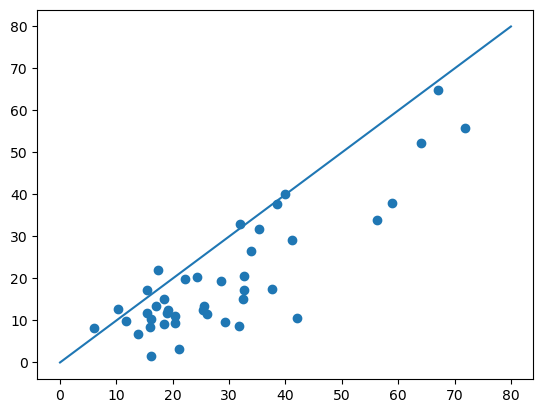

In [37]:
plt.plot([0, 80], [0,80])
plt.scatter(std_FR0, std_FR1)

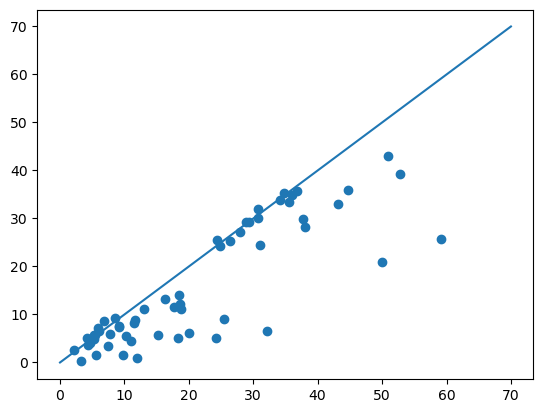

In [275]:
plt.plot([0, 70], [0,70])
plt.scatter(mean_FR0, mean_FR1)

In [5]:
Robs = deepcopy(data[0][:]['robs']).numpy()

In [11]:
np.sum(Robs[:,-1])

63370.0

In [4]:
MCmodel_folders = ['MCmodels'] * len(expt_names)
MCmodel_folders[expt_names == 'J250529'] = 'MCmodels_SU'

model_type = 'gqm'
model_prefixes = ['C0', 'C1', 'SH0', 'SH1']

expr = '^' + f"({'|'.join(model_prefixes)})" + f".*?{model_type}(\d+)\.ndn$"

pattern = re.compile(expr)
model_dir_dicts = []

for i, expt in enumerate(expt_names):
    model_dir_dict = {k: [] for k in model_prefixes}
    fnames = os.listdir(f"{datadir}{expt}/{MCmodel_folders[i]}")
    for f in fnames:
        m = pattern.match(f)
        if m:
            prefix, num = m.groups()
            model_dir_dict[prefix].append(int(num))
    for k in model_dir_dict:
        model_dir_dict[k].sort()
    model_dir_dicts.append(model_dir_dict)

# for each expt, find low contrast model prefix with most models, and high contrast model prefix with most models

prefix1 = []
prefix0 = []
NC0 = []
NC1 = []
for i in range(len(expt_names)):
    
    max_0 = max((k for k in model_dir_dicts[i] if k.endswith('0')), key=lambda k: len(model_dir_dicts[i][k]))
    max_1 = max((k for k in model_dir_dicts[i] if k.endswith('1')), key=lambda k: len(model_dir_dicts[i][k]))

    prefix1.append(max_1)
    prefix0.append(max_0)

NC0 = []
NC1 = []
for i in range(len(expt_names)):
    NC0.append(model_dir_dicts[i][prefix0[i]])
    NC1.append(model_dir_dicts[i][prefix1[i]])

NC = [np.intersect1d(a,b) for a,b in zip(NC0, NC1)]

## Load GQMs

In [5]:

dt = 1/60

mean_FR0 = []
mean_FR1 =[]

std_FR0 = []
std_FR1 = []

for expt in range(len(expt_names)):
    
    Robs = deepcopy(data[expt][:]['robs']).numpy()
    dfs = deepcopy(data[expt][:]['dfs']).numpy()
    
    c1 = np.where(data[expt].file_info[0]['cloud_info'][data[expt].tranges,0] > 1)[1]
    c0 = np.where(data[expt].file_info[0]['cloud_info'][data[expt].tranges,0] < 1)[1]  # high contras
    
    Robs0 = deepcopy(Robs[c0,:])
    Robs1 = deepcopy(Robs[c1,:])
    dfs0 = deepcopy(dfs[c0,:])
    dfs1 = deepcopy(dfs[c1,:])
    
    N0 = np.sum(dfs0,axis=0)
    N1 = np.sum(dfs1, axis=0)
    
    Reff0 = (1/dt)*Robs0*dfs0
    Reff1 = (1/dt)*Robs1*dfs1
    
    mean_FR0.append(np.sum(Reff0,axis=0 )/N0)
    mean_FR1.append(np.sum(Reff1,axis=0)/N1)

    std_FR0.append(np.sqrt(np.sum((Reff0 - mean_FR0[expt])**2, axis=0)/(N0-1)))
    std_FR1.append(np.sqrt(np.sum((Reff1 - mean_FR1[expt])**2,axis=0)/(N1-1)))


mean_FR0 = np.concatenate(mean_FR0)
mean_FR1 = np.concatenate(mean_FR1)
std_FR0 = np.concatenate(std_FR0)
std_FR1 = np.concatenate(std_FR1)



/tmp/ipykernel_754374/666698023.py:28: RuntimeWarning: invalid value encountered in divide
  mean_FR0.append(np.sum(Reff0,axis=0 )/N0)
/tmp/ipykernel_754374/666698023.py:29: RuntimeWarning: invalid value encountered in divide
  mean_FR1.append(np.sum(Reff1,axis=0)/N1)


In [6]:
gqms0 = [
    [
        NDN.load_model(f"{datadir}{expt}/{mc_folder}/{prefix}gqm{utils.filename_num2str(cc, 3)}")
        for cc in nc
    ]
    for expt, mc_folder, prefix, nc in zip(expt_names, MCmodel_folders, prefix0, NC)
]

gqms1 = [
    [
        NDN.load_model(f"{datadir}{expt}/{mc_folder}/{prefix}gqm{utils.filename_num2str(cc, 3)}")
        for cc in nc
    ]
    for expt, mc_folder, prefix, nc in zip(expt_names, MCmodel_folders, prefix1, NC)
]

## Make dataframe with info about good GQMs

In [7]:
rows = []

counter = 0
for i in range(len(expt_names)):
    for cc in NC[i]:
        try:
            filters0 = get_weighted_filters(gqms0[i][cc], data[i], cc)
            filters1 = get_weighted_filters(gqms1[i][cc], data[i], cc)
        except:
            continue

        for chrom in chrom_chan_labels:
            #chrom_chan_label = chrom_chan_labels[chrom]

            for f in f_labels:
               # f_label = f_labels[f]

                isGood0, best_lag0,_ = assess_quality(filters0, chrom, f)
                isGood1, best_lag1,_ = assess_quality(filters1, chrom, f)

                if not (isGood0 and isGood1):
                    continue

                RFarea0, ON0, OFF0, dom0 = analyze_RF_structure(
                    filters0, chrom, f, best_lag0
                )

                RFarea1, ON1, OFF1, dom1 = analyze_RF_structure(
                    filters1, chrom, f, best_lag1
                )

                if dom0:
                    subunitArea0 = ON0
                else:
                    subunitArea0 = OFF0

                if dom1:
                    subunitArea1 = ON1
                else:
                    subunitArea1 = OFF1

                rows.append({
                    "expt_num": i,
                    "cc": cc,
                    "f": f,
                    "chrom": chrom,

                    "RFarea0": RFarea0,
                    "ON_RFarea0": ON0,
                    "OFF_RFarea0": OFF0,
                    "subunitArea0": subunitArea0,
                    "best_lag0": best_lag0,

                    "RFarea1": RFarea1,
                    "ON_RFarea1": ON1,
                    "OFF_RFarea1": OFF1,
                    "subunitArea1": subunitArea1,
                    "best_lag1": best_lag1,

                    "mean_FR0": mean_FR0[counter],
                    "mean_FR1": mean_FR1[counter],
                    "std_FR0": std_FR0[counter],
                    "std_FR1": std_FR1[counter]})
                })
            counter+=1

In [13]:
FR_rows = []

counter = 0
for i in range(len(expt_names)):
    for cc in NC[i]:
        FR_rows.append({"expt_num":i,
                     "cc":cc,
                     "mean_FR0": mean_FR0[counter],
                     "mean_FR1": mean_FR1[counter],
                     "std_FR0": std_FR0[counter],
                     "std_FR1": std_FR1[counter]})
        counter+=1
        

In [15]:
df_FR_Jocamo = pd.DataFrame(FR_rows)
df_FR_Jocamo.to_csv('/home/bevil/df_FR_Jocamo.csv', index=False)

In [8]:
import pandas as pd

df = pd.DataFrame(rows)

In [9]:
df

,expt_num,cc,f,chrom,RFarea0,ON_RFarea0,OFF_RFarea0,subunitArea0,best_lag0,RFarea1,ON_RFarea1,OFF_RFarea1,subunitArea1,best_lag1
0,0,0,lin,Lum,242,127,115,115,6,243,128,115,115,6
1,0,1,lin,Lum,208,111,97,111,6,209,111,98,111,6
2,0,1,q1,Lum,140,60,80,60,6,114,16,98,98,5
3,0,2,lin,Lum,185,65,120,65,5,184,65,119,65,5
4,0,2,q1,Lum,209,159,50,50,6,214,164,50,50,6
5,0,3,lin,Lum,172,65,107,107,5,171,64,107,107,5
6,0,3,lin,S,458,183,275,275,5,459,183,276,276,5
7,0,5,q1,Lum,154,75,79,79,6,162,78,84,78,6
8,0,5,q2,Lum,188,81,107,81,6,194,78,116,78,6
9,0,6,lin,L-M,121,62,59,62,5,120,62,58,62,5


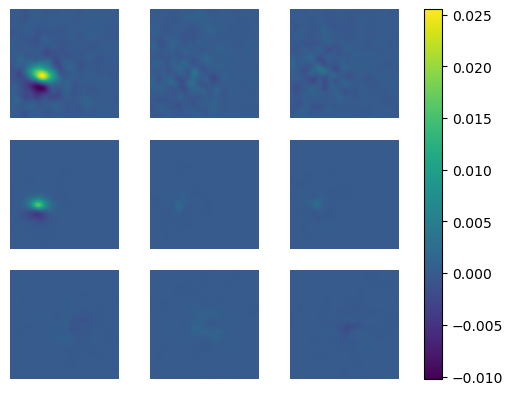

In [83]:

gqm = deepcopy(gqms0[0][1])
wL = deepcopy(gqm.get_weights())
wQ = deepcopy(gqm.get_weights(ffnet_target=2))
filters = np.concatenate([wL, wQ], axis=4)
fig, axs = plt.subplots(3,3)

lag = 6
im = None  # will hold the last image

for f in range(3):
    for chrom in range(3):
        im = axs[f,chrom].imshow(
            np.rot90(filters[chrom,:,:,lag,f]),
            vmin=np.min(filters[:,:,:,lag,:]),
            vmax=np.max(filters[:,:,:,lag,:]),
            cmap='viridis'
        )
        axs[f,chrom].set_axis_off()

fig.colorbar(im, ax=axs)


plt.savefig('/home/bevil/J250529_cell1_HC_w_colorbar.eps')

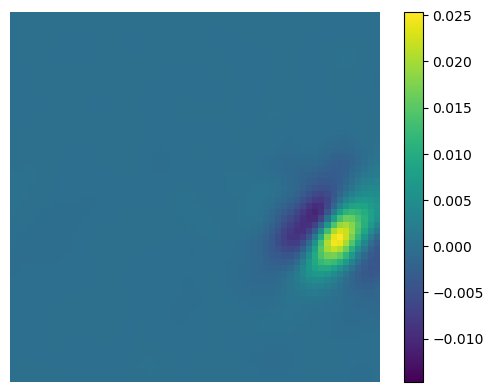

In [86]:
gqm = deepcopy(gqms0[0][5])
wL = deepcopy(gqm.get_weights())
wQ = deepcopy(gqm.get_weights(ffnet_target=2))
filters = np.concatenate([wL, wQ], axis=4)

plt.imshow(np.rot90(filters[0,:,:,5,1]), vmin= np.min(filters[:,:,:,5,:]), vmax = np.max(filters[:,:,:,5,:]) )
plt.axis('off')

plt.colorbar()
plt.savefig('/home/bevil/J250529_cell5_Lum_q1_w_colorbar.eps')


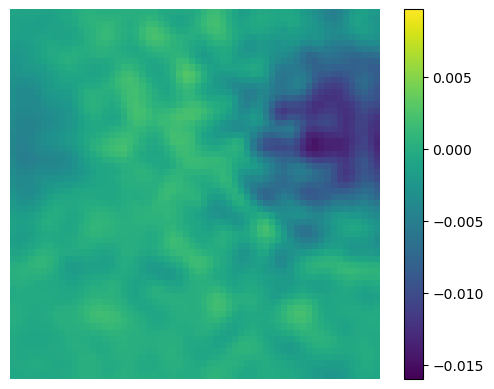

In [82]:
gqm = deepcopy(gqms0[0][18])
wL = deepcopy(gqm.get_weights())
wQ = deepcopy(gqm.get_weights(ffnet_target=2))
filters = np.concatenate([wL, wQ], axis=4)

plt.imshow(np.rot90(filters[1,:,:,5,0]), vmin= np.min(filters[:,:,:,5,:]), vmax = np.max(filters[:,:,:,5,:]) )
plt.axis('off')
plt.colorbar()
plt.savefig('/home/bevil/J250529_cell18_LM_lin_w_colorbar.eps')


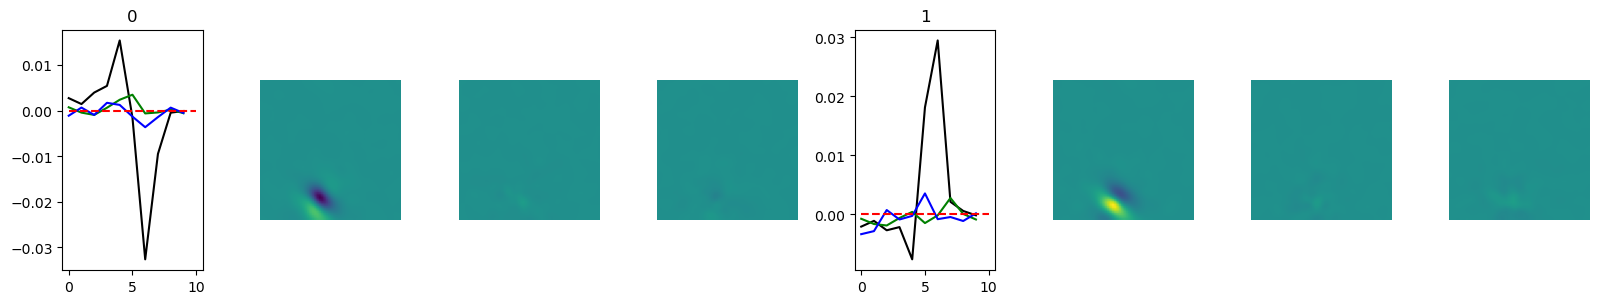

In [65]:
gqms0[0][5].plot_filters(ffnet_target=2)

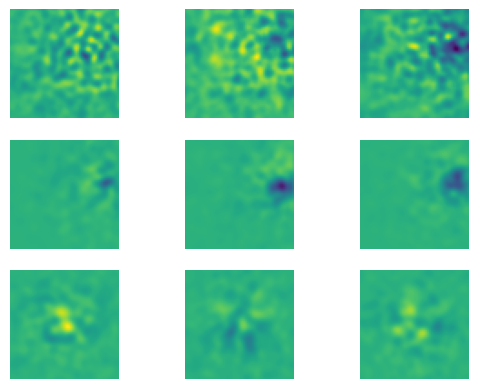

In [31]:
gqm = deepcopy(gqms1[0][18])
wL = deepcopy(gqm.get_weights())
wQ = deepcopy(gqm.get_weights(ffnet_target=2))
filters = np.concatenate([wL, wQ], axis=4)
fig, axs = plt.subplots(3,3)
lag = 3
for f in range(3):
    for chrom in range(3):
        axs[f,chrom].imshow(np.rot90(filters[chrom,:,:,lag,f]), vmin= np.min(filters[:,:,:,lag,:]), vmax = np.max(filters[:,:,:,lag,:]) )
        axs[f,chrom].set_axis_off()
#plt.savefig('/home/bevil/J250529_cell1_LC.eps')

In [157]:
filters = get_weighted_filters(gqms0[0][1], data[0], 1)

In [162]:
chrom_chan_label = "Lum"
f_label = "q2"

chrom_chan = chrom_chan_labels.index(chrom_chan_label)
f = f_labels.index(f_label)
n_chrom_chan, NX, NY, nlags, n_filts = filters.shape
filters2 = filters ** 2
filters2_ON = np.where(filters > 0, filters2, 0)
filters2_OFF = np.where(filters < 0, filters2, 0)

filters2_std = np.reshape(np.std(filters2, axis=3), (n_chrom_chan, NX, NY, n_filts)) 
thisFilter_std = np.reshape(filters2_std[chrom_chan,:,:,f], (NX, NY))
mask = get_mask(thisFilter_std)

# determine ON and OFF subunits
ON_RF = np.reshape(filters2_ON[chrom_chan,:,:,best_lag,f], (NX, NY)) * mask
OFF_RF = np.reshape(filters2_OFF[chrom_chan,:,:,best_lag,f], (NX, NY)) * mask

# compute rms of ON and OFF subunits
ON_RF_rms = np.sqrt(np.mean(ON_RF**2))
OFF_RF_rms = np.sqrt(np.mean(OFF_RF**2))

# binarize ON and OFF subunit images and compute area by summing pixels in binarized images
ON_RF_bin = (ON_RF > 0.05 * np.max(ON_RF))
ON_RFarea = np.sum(ON_RF_bin)

OFF_RF_bin = (OFF_RF > 0.05 * np.max(OFF_RF))
OFF_RFarea = np.sum(OFF_RF_bin)




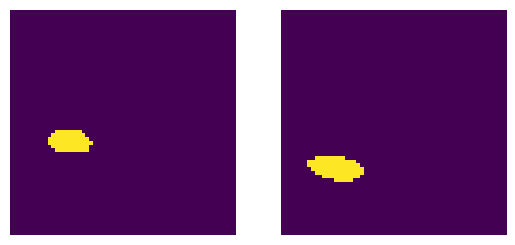

In [169]:
fig, axs = plt.subplots(1,2)
axs[0].imshow(np.rot90(ON_RF_bin))
axs[0].set_axis_off()
axs[1].imshow(np.rot90(OFF_RF_bin))
axs[1].set_axis_off()

plt.savefig('/home/bevil/J250529_cell1_ON_OFF_masks_HC.eps')

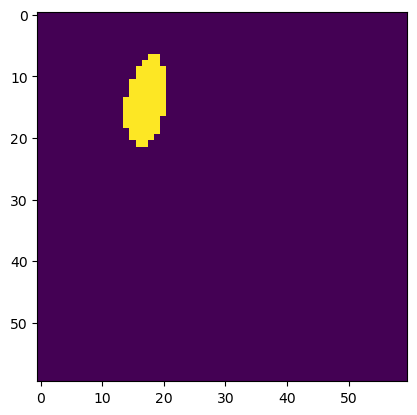

In [165]:
plt.imshow(OFF_RF_bin)

In [12]:
df.to_csv('/home/bevil/VSS_df.csv', index=False)

(175, 122, 53, True)

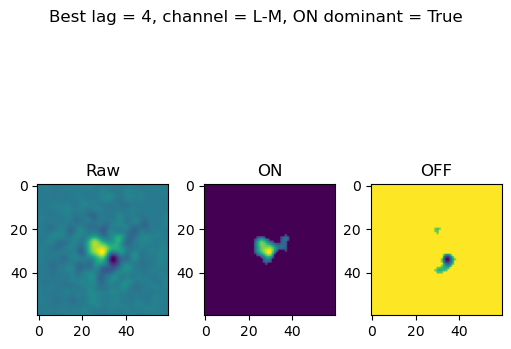

In [27]:
# # Show results of analysis on ith row of df
# i=1
# expt_num = df['expt_num'][i]
# cc = df['cc'][i]
# chrom_chan_label = df['chrom'][i]
# f_label = df['f'][i]

# chrom_chan_label="S"
# f_label = 'lin'

expt_num=3
cc= 1
chrom_chan_label= 'L-M'
f_label='q1'

f = f_labels.index(f_label)
chrom_chan = chrom_chan_labels.index(chrom_chan_label)

filters = get_weighted_filters(gqms1[expt_num][cc], data[expt_num], cc)
isgood,best_lag,metrics = assess_quality(filters, chrom_chan_label, f_label)

analyze_RF_structure(filters, chrom_chan_label, f_label, best_lag, toPlot=1)

In [28]:
metrics

{'SNR_db': 5.867286144661065,
 'tkern_mean_crossings': 3,
 'tkern_slope': 0.41752603816191164,
 'spatial_pr': 90.96094671150772,
 'tv_sf': 0.8742934109356696,
 'num_tkern_extrema': 2,
 'tkern_first_deriv_energy': 2.204478678847822}

In [29]:
isgood

True

(209, 111, 98, True)

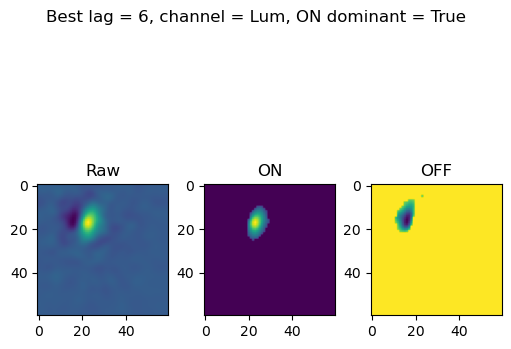

In [154]:
filters = get_weighted_filters(gqms1[expt_num][cc], data[expt_num], cc)
isgood,best_lag,metrics = assess_quality(filters, chrom_chan_label, f_label)
analyze_RF_structure(filters, chrom_chan_label, f_label, best_lag, toPlot=1)

In [155]:
print(isgood)
print(metrics)

True
{'SNR_db': 11.542055606842041, 'tkern_mean_crossings': 2, 'tkern_slope': 0.09772499, 'spatial_pr': 49.04686022480797, 'tv_sf': 0.7385979678739278, 'num_tkern_extrema': 2, 'tkern_first_deriv_energy': 2.319819}


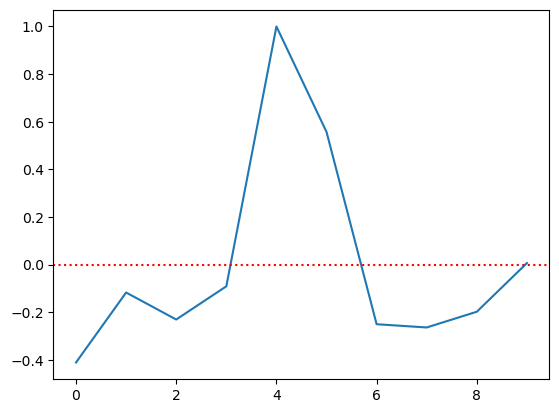

In [30]:


n_chrom_chan, NX, NY, nlags, n_filts = filters.shape
filters2 = filters ** 2
filters2_std = np.reshape(np.std(filters2, axis=3), (n_chrom_chan, NX, NY, n_filts))     
thisFilter_std = np.reshape(filters2_std[chrom_chan,:,:,f], (NX, NY))
best_row, best_col = np.where(thisFilter_std == np.max(thisFilter_std))
tkern = np.ravel(filters[chrom_chan,best_row,best_col,:,f].reshape(10,-1))
# plt.imshow(filters[chrom_chan,:,:,best_lag,f])
# plt.plot(best_col, best_row, 'rx')

tkern_standardized = deepcopy(tkern)
tkern_standardized -= tkern.mean()
tkern_standardized /= np.max(np.abs(tkern_standardized))
plt.plot(tkern_standardized)
plt.axhline(y=np.mean(tkern_standardized), color='r', linestyle=':') # Red dashed line at y=10

In [38]:
np.sum((np.diff(tkern_standardized)**2))

6.9365377

In [344]:

filter_at_best_lag = np.reshape(filters[chrom_chan, :,:,best_lag, f], (NX, NY))
F = np.fft.fftshift(np.fft.fft2(filter_at_best_lag))
P = np.abs(F)**2
#P = P.ravel()
pr = (P.sum()**2)/np.sum(P**2)

h,w = filter_at_best_lag.shape

ky, kx = np.mgrid[-h//2:h//2, -w//2:w//2]
r = np.sqrt(kx**2 + ky**2)
hf = np.sum((r**2) * P) / np.sum(P)

print(pr)
print(hf)

87.72812660383707
15.073613920570276


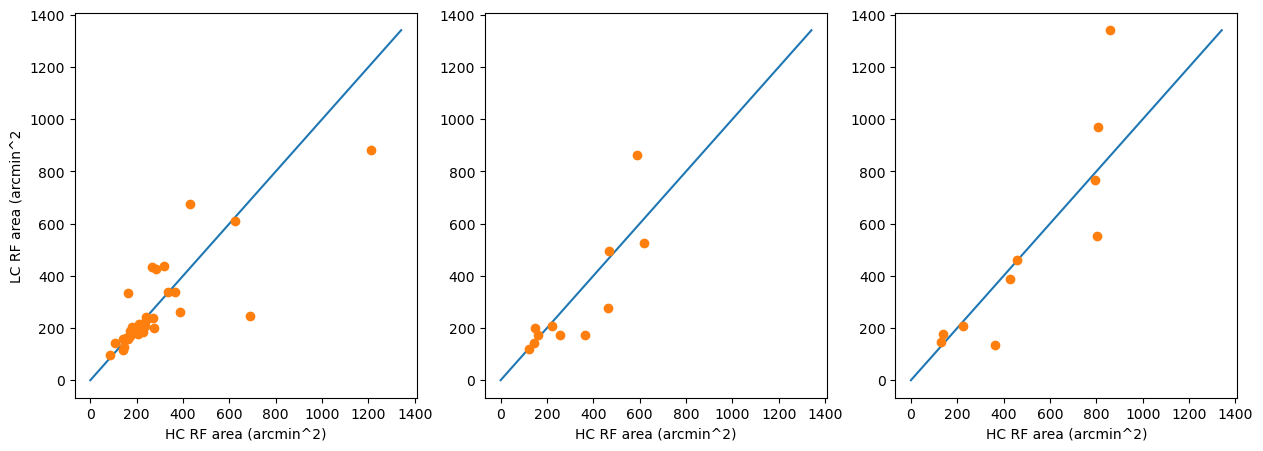

In [137]:
# for each channel, plot LC vs HC RF area

fig, axs = plt.subplots(1, len(chrom_chan_labels), figsize=(15,5))

for i, chrom_chan in enumerate(chrom_chan_labels):
    temp_df = df[df["chrom"] == chrom_chan]
    RFarea_HC = temp_df["RFarea0"]
    RFarea_LC = temp_df["RFarea1"]
    axMax = np.max(df[["RFarea1", "RFarea0"]])
    axs[i].plot([0,axMax], [0, axMax])
    axs[i].plot(RFarea_HC, RFarea_LC, marker='o', linestyle='none')
    axs[i].set_xlabel("HC RF area (arcmin^2)")
    if i == 0:
        axs[i].set_ylabel("LC RF area (arcmin^2")


In [ ]:
np.max(df[["RFarea1", "RFarea0"]])

In [2]:
expt_names_S = ['S260505'] # 'J250930' doesnt have gqms for both contrasts
num_lags=10
cmeS = []
dataS = []

for i in range(len(expt_names_S)):
    cmeS.append(cme.MultiExperiment(names=[expt_names_S[i]], datadir=datadir, array_types='LAM', include_MUs=False,
    num_lags=num_lags, luminance_only=False,  # suggest doing non-color first to understand 
    block_sample=False))
    dataS.append(cmeS[i].build_stim(LMS=False, top_corner = (1025-30, 573-30)))  ####### DKL SPACE


S260505: Loading post-processing file: /home/DATA/ColorV1/S260505/postproc/postproc260510.mat
  DFs loaded with shape: (313680, 62)
Read in 1307 trial times
Loading /home/DATA/ColorV1/S260505/Analysis/ddpi_cal7.hd5 ...
  Separating trials...


100%|███████████████████████████████████████| 1305/1305 [00:55<00:00, 23.57it/s]


  Downsampling...
Done.
Left:      3.820 (H)	  3.603 (V)
Right:     2.838 (H)	  5.477 (V)
Binoc dE:  0.983 (H)	  1.875 (V)
Binocular StDev: [2.95363973 6.51817352 7.37044714]
Binoc-sm0 StDev: [2.73798992 6.46432306 7.24203635]
Zeroing mean positions.
Adjusting downsample.... Done.
  No legacy stimpos files found in /home/DATA/ColorV1/S260505/Analysis/
Loading: S260505/Analysis/Sprout_260505_laminar_CC_ETNA_v09.mat  
MULTIDATASET 1 expts: 313680 total time steps, 62 units
Partitioned 1307 blocks total: tr 837, val 209, te 261
Pre-valid data indices: tr 200880, val 50160, te 62640
  Trials included: 2 to 1306
  Redoing cross-validation indices
here
Done.
  Shifts: averaging L and R eye positions
  Stim expansion for shift: [975, 523, 1075, 623]
  Writing lam stim 0: overlap 50, 50
  Writing lam stim 1: overlap 50, 50
  Writing lam stim 2: overlap 50, 50
  Writing lam stim 3: overlap 50, 50
  Shifting stim...


100%|███████████████████████████████████████████| 63/63 [00:32<00:00,  1.95it/s]


  CROP: New stim size: 60 x 60
  Done: expt 0
Stimulus assembly complete


In [3]:
NC = cmeS[0].data.NC

In [13]:
cell_lists = []

for i, expt_name in enumerate(expt_names_S):
    fns = pproc.cloud_filenames(datadir, expt_name)
    cell_list = sio.loadmat(fns['procfile'])['cell_list'][0][:NC]

In [16]:
cell_list

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 11, 12, 13, 14, 15, 16, 17, 18,
       20, 22, 23, 25, 26, 28, 30, 32, 33, 36, 37, 39, 41, 42, 44, 45, 47,
       48, 50, 51, 52, 53, 54, 56, 58, 59, 60, 61])

In [31]:

dt = 1/60

mean_FR0 = []
mean_FR1 =[]

std_FR0 = []
std_FR1 = []

for expt in range(len(expt_names_S)):
    
    Robs = deepcopy(dataS[expt][:]['robs']).numpy()
    dfs = deepcopy(dataS[expt][:]['dfs']).numpy()
    
    c1 = np.where(dataS[expt].file_info[0]['cloud_info'][dataS[expt].tranges,0] > 1)[1]
    c0 = np.where(dataS[expt].file_info[0]['cloud_info'][dataS[expt].tranges,0] < 1)[1]  # high contras
    
    Robs0 = deepcopy(Robs[c0,:])
    Robs1 = deepcopy(Robs[c1,:])
    dfs0 = deepcopy(dfs[c0,:])
    dfs1 = deepcopy(dfs[c1,:])
    
    N0 = np.sum(dfs0,axis=0)
    N1 = np.sum(dfs1, axis=0)
    
    Reff0 = (1/dt)*Robs0*dfs0
    Reff1 = (1/dt)*Robs1*dfs1
    
    mean_FR0.append(np.sum(Reff0,axis=0 )/N0)
    mean_FR1.append(np.sum(Reff1,axis=0)/N1)

    std_FR0.append(np.sqrt(np.sum((Reff0 - mean_FR0[expt])**2, axis=0)/(N0-1)))
    std_FR1.append(np.sqrt(np.sum((Reff1 - mean_FR1[expt])**2,axis=0)/(N1-1)))


mean_FR0 = np.concatenate(mean_FR0)
mean_FR1 = np.concatenate(mean_FR1)
std_FR0 = np.concatenate(std_FR0)
std_FR1 = np.concatenate(std_FR1)



/tmp/ipykernel_707231/2404450633.py:28: RuntimeWarning: invalid value encountered in divide
  mean_FR0.append(np.sum(Reff0,axis=0 )/N0)
/tmp/ipykernel_707231/2404450633.py:29: RuntimeWarning: invalid value encountered in divide
  mean_FR1.append(np.sum(Reff1,axis=0)/N1)


In [7]:
expt=0
Robs = deepcopy(data[expt][:]['robs']).numpy()


In [17]:
np.sum(Robs[:,0])

94678.0

In [34]:
FR_rows_S = []

counter = 0
for i in range(len(expt_names_S)):
    for cc in range(NC):
        FR_rows_S.append({"expt_num":i,
                     "cc":cc,
                     "mean_FR0": mean_FR0[counter],
                     "mean_FR1": mean_FR1[counter],
                     "std_FR0": std_FR0[counter],
                     "std_FR1": std_FR1[counter]})
        counter+=1
df_FR_Sprout = pd.DataFrame(FR_rows_S)
df_FR_Sprout.to_csv('/home/bevil/df_FR_Sprout.csv', index=False)

In [35]:
df_FR_Sprout

,expt_num,cc,mean_FR0,mean_FR1,std_FR0,std_FR1
0,0,0,10.670274,2.289223,25.347542,12.482618
1,0,1,0.575744,0.963297,5.991992,8.154356
2,0,2,53.443256,45.331978,67.020493,64.878860
3,0,3,24.684813,26.068140,39.886463,39.999496
4,0,4,16.910156,4.000274,37.609921,17.582483
5,0,5,4.531916,2.765348,16.979300,13.367766
6,0,6,4.146537,1.120809,15.978265,8.360826
7,0,7,3.101713,1.933987,19.095619,12.411865
8,0,8,4.532444,3.094419,18.475166,15.123952
9,0,9,13.974695,6.008612,33.945320,26.546900


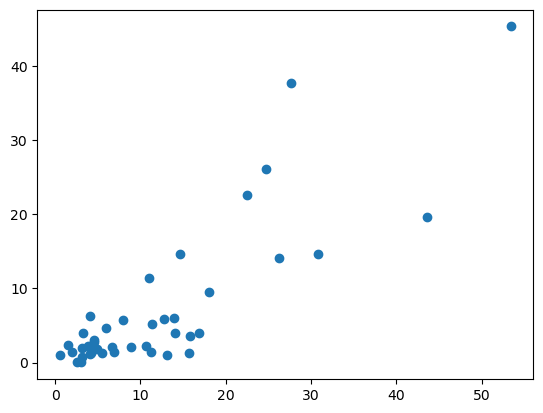

In [36]:
plt.scatter(mean_FR0, mean_FR1)